# Fine-Tuning YOLO for License-Plate Detection

Yesterday we *ran* a pretrained YOLO. Today we **fine-tune** one on our own data — teaching it to detect **car license plates** — then run it on a **traffic video**.

**The full pipeline:**
1. **Convert the data** — the dataset is in Pascal-VOC (XML) format; YOLO needs its own format. We convert it (a real-world skill).
2. **Split** into train/val and write a `data.yaml`.
3. **Fine-tune** `yolov8n` on the plates.
4. **Evaluate** with mAP (the detection metric).
5. **Run on a video** and save the annotated output.

> **Setup on Kaggle:**
> - Settings → Accelerator → **GPU**.
> - Add Input → the **"Car License Plate Detection"** dataset (`andrewmvd/car-plate-detection`).
> - Add Input → **your traffic/dashcam video** (upload it as a dataset).
> - Turn **Internet ON** (needed to pip-install ultralytics + download the base weights).

In [1]:
!pip install ultralytics --quiet

import os, glob, shutil, random
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
from ultralytics import YOLO

random.seed(42)
print("ready")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 15.9 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 3.0 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
ready


In [2]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [3]:
import pandas as pd

In [4]:
import torch
print("pytorch version:",torch.__version__)
print("CUDA available: ",torch.cuda.is_available())

if torch.cuda.is_available():
    print("gPU : ",torch.cuda.get_device_name(0))

pytorch version: 2.10.0+cu128
CUDA available:  True
gPU :  Tesla T4


In [5]:
fruit_path ="/kaggle/input/datasets/chrisfilo/fruit-recognition"

In [6]:
VALID_EXT="jpeg","jpg","png"
image_path= []
class_name =[]
label =[]
for index,name in enumerate(os.listdir(fruit_path)):
    first_internal_path=os.path.join(fruit_path,name)
    for picture in os.listdir(first_internal_path):
        image =os.path.join(first_internal_path,picture)
        if picture.lower().endswith(VALID_EXT):
            image_path.append(image)
            class_name.append(name)
            label.append(index)
        else:
            for another in os.listdir(image):
                second_internal_path= os.path.join(image,another)
                if another.lower().endswith(VALID_EXT):
                    image_path.append(second_internal_path)
                    class_name.append(name)
                    label.append(index)

        
        

In [7]:
len(image_path)

70549

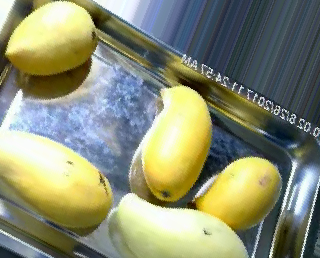

In [8]:
Image.open(image_path[70450])

In [9]:
class_name[1]

'Orange'

In [10]:
label[70540]

14

In [11]:
print("Number of images:", len(image_path))
print("Number of class names:", len(class_name))
print("Number of labels:", len(label))

# These three numbers MUST be equal.
assert len(image_path) == len(class_name) == len(label)

print("\nEverything matches!")

Number of images: 70549
Number of class names: 70549
Number of labels: 70549

Everything matches!


In [12]:
df = pd.DataFrame({
    "image_path": image_path,
    "class_name": class_name,
    "label": label
})

print(df.head())
print("\nDataset shape:", df.shape)

                                          image_path class_name  label
0  /kaggle/input/datasets/chrisfilo/fruit-recogni...     Orange      0
1  /kaggle/input/datasets/chrisfilo/fruit-recogni...     Orange      0
2  /kaggle/input/datasets/chrisfilo/fruit-recogni...     Orange      0
3  /kaggle/input/datasets/chrisfilo/fruit-recogni...     Orange      0
4  /kaggle/input/datasets/chrisfilo/fruit-recogni...     Orange      0

Dataset shape: (70549, 3)


In [13]:
len(df.class_name.unique())

15

In [14]:
from ultralytics import SAM

In [15]:
sam = SAM("sam2.1_l.pt")

In [16]:
results = sam.predict(image_path[70450],save = True,verbose=True)
print(type(results))
print(results[0])


image 1/1 /kaggle/input/datasets/chrisfilo/fruit-recognition/Mango/Mango00234.png: 1024x1024 1 0, 1 1, 1 2, 1 3, 1 4, 1 5, 1 6, 1 7, 11312.7ms
Speed: 78.5ms preprocess, 11312.7ms inference, 0.9ms postprocess per image at shape (1, 3, 1024, 1024)
Results saved to /kaggle/working/runs/segment/predict
<class 'list'>
ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
depth: None
keypoints: None
masks: ultralytics.engine.results.Masks object
names: {0: '0', 1: '1', 2: '2', 3: '3', 4: '4', 5: '5', 6: '6', 7: '7'}
obb: None
orig_img: array([[[243, 254, 250],
        [243, 254, 250],
        [245, 254, 247],
        ...,
        [ 81,  76,  65],
        [ 81,  76,  65],
        [ 79,  74,  62]],

       [[243, 254, 250],
        [243, 254, 250],
        [243, 254, 250],
        ...,
        [ 81,  76,  65],
        [ 79,  74,  62],
        [ 79,  74,  62]],

       [[242, 254, 250],
        [242, 254, 250],
        [243, 254, 250],
     

In [17]:
l =[]

In [18]:
l.append(results[0].boxes.xywhn[0])

In [24]:
for i in label:
    print(i)
    break

0


In [35]:
l=[]

In [36]:
for path,fruit,idx in zip(image_path,class_name,label):
    l.append([str(path),
              str(fruit),
              idx,
              results[0].boxes.xywhn.cpu().tolist()]
            )
    break

In [37]:
l

[['/kaggle/input/datasets/chrisfilo/fruit-recognition/Orange/Orange001194.png',
  'Orange',
  0,
  [[0.16015625, 0.14898255467414856, 0.2890625, 0.2906976640224457],
   [0.17626953125, 0.6976743936538696, 0.3525390625, 0.38759690523147583],
   [0.55712890625, 0.8745154738426208, 0.4404296875, 0.24951550364494324],
   [0.744140625, 0.7515746355056763, 0.2734375, 0.28706395626068115],
   [0.53271484375, 0.557776153087616, 0.2607421875, 0.4542151093482971],
   [0.02294921875, 0.06480135768651962, 0.0458984375, 0.12960271537303925],
   [0.03466796875, 0.976865291595459, 0.0693359375, 0.04481589049100876],
   [0.1328125, 0.01877422444522381, 0.060546875, 0.03754844889044762]]]]

In [38]:
record = l[0]

In [40]:
boxes = record[3]

In [41]:
for box in boxes:
    xcenter,ycenter,width,height=box
    print(xcenter,ycenter,width,height)

0.16015625 0.14898255467414856 0.2890625 0.2906976640224457
0.17626953125 0.6976743936538696 0.3525390625 0.38759690523147583
0.55712890625 0.8745154738426208 0.4404296875 0.24951550364494324
0.744140625 0.7515746355056763 0.2734375 0.28706395626068115
0.53271484375 0.557776153087616 0.2607421875 0.4542151093482971
0.02294921875 0.06480135768651962 0.0458984375 0.12960271537303925
0.03466796875 0.976865291595459 0.0693359375 0.04481589049100876
0.1328125 0.01877422444522381 0.060546875 0.03754844889044762


In [42]:
for box in boxes:
    x_center, y_center, width, height = box

    f.write(
        f"{class_id} {x_center} {y_center} {width} {height}\n"
    )

NameError: name 'f' is not defined

In [45]:
output_dir = "/kaggle/working/labels"
os.makedirs(output_dir,exist_ok=True)

In [53]:
os.path.basename("/kaggle/input/datasets/chrisfilo/fruit-recognition/Apple/Apple A/Apple 1.png")

'Apple 1.png'

In [52]:
os.path.splitext(os.path.basename("/kaggle/input/datasets/chrisfilo/fruit-recognition/Apple/Apple A/Apple 1.png"))[0]+".txt"

IndexError: tuple index out of range

In [54]:
for path,fruit,idx in zip(image_path,class_name,label):
    results = sam.predict(path,verbose =False)

    boxes =results[0].boxes.xywhn.cpu().tolist()

    filename = os.path.splitext(os.path.basename(path))[0]+".txt"

    txt_path = os.path.join(output_dir,filename)

    with open(txt_path,"w") as f:
        for box in boxes:
            xcenter,ycenter,width,height =box
            f.write(f"{idx} {xcenter} {ycenter} {width} {height}\n")

KeyboardInterrupt: 

In [ ]:
def generate_annotation(data_with_info,sam_model):

In [ ]:
results[0].boxes.xyxy

In [ ]:
Image.open("/kaggle/working/runs/segment/predict/Mango00234.jpg")

In [ ]:
yolmodel= YOLO("yolov10n.pt")

In [ ]:
reyolo= yolmodel.predict(image_path[70450],save = True,conf= 0.25)

In [ ]:
Image.open("/kaggle/working/runs/detect/predict/Mango00234.jpg")

## 1. Look at the raw dataset

The Kaggle dataset has two folders:
- `images/` — the car photos (`.png`)
- `annotations/` — one **Pascal-VOC XML** per image, with the plate's bounding box.

Let's confirm the paths and peek at one XML.

In [ ]:
import torch

In [ ]:
import torch

In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

In [ ]:
# adjust if your Kaggle path differs (check the right-hand file browser)
SRC = "/kaggle/input/datasets/chrisfilo/fruit-recognition"
IMG_SRC = os.path.join(SRC, "images")
ANN_SRC = os.path.join(SRC, "annotations")

images = sorted(glob.glob(os.path.join(IMG_SRC, "*.png")))
anns   = sorted(glob.glob(os.path.join(ANN_SRC, "*.xml")))
print("images:", len(images), " annotations:", len(anns))

# peek at one annotation
print("\nexample XML:\n")
print(open(anns[0]).read()[:500])

In [ ]:
SRC = "/kaggle/input/datasets/chrisfilo/fruit-recognition"
os.listdir(SRC)

In [ ]:
print("pytorch version: ",torch.__version__)
print("CUDA available: ",torch.cuda.is_available())

## 2. Convert Pascal-VOC (XML) → YOLO format

**Why:** VOC stores boxes as pixel corners `[xmin, ymin, xmax, ymax]`. YOLO wants, per object, one line:
```
class_id  x_center  y_center  width  height     (all normalized 0-1)
```
We have one class — `licence` → class id **0**. This conversion is a genuine everyday task: real datasets rarely arrive in the format your tool wants.

In [ ]:
def voc_to_yolo(xml_path):
    """Read one VOC xml, return list of YOLO lines 'class cx cy w h' (normalized)."""
    root = ET.parse(xml_path).getroot()
    W = int(root.find("size/width").text)
    H = int(root.find("size/height").text)
    lines = []
    for obj in root.findall("object"):
        b = obj.find("bndbox")
        xmin, ymin = float(b.find("xmin").text), float(b.find("ymin").text)
        xmax, ymax = float(b.find("xmax").text), float(b.find("ymax").text)
        cx = (xmin + xmax) / 2 / W
        cy = (ymin + ymax) / 2 / H
        w  = (xmax - xmin) / W
        h  = (ymax - ymin) / H
        lines.append(f"0 {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}")   # class 0 = licence
    return lines

# test on one file
print("converted example:", voc_to_yolo(anns[0]))

## 3. Build the YOLO dataset folders (train/val split)

YOLO expects this layout:
```
dataset/
  images/train/  images/val/
  labels/train/  labels/val/
```
We copy each image to the right split and write its converted `.txt` label alongside.

In [ ]:
ROOT = "/kaggle/working/plates"
for sub in ["images/train", "images/val", "labels/train", "labels/val"]:
    os.makedirs(os.path.join(ROOT, sub), exist_ok=True)

# pair each image with its annotation by matching filename stem
stems = [os.path.splitext(os.path.basename(p))[0] for p in images]
random.shuffle(stems)
split = int(0.8 * len(stems))
train_stems, val_stems = stems[:split], stems[split:]

def build_split(stem_list, split_name):
    for stem in stem_list:
        img = os.path.join(IMG_SRC, stem + ".png")
        xml = os.path.join(ANN_SRC, stem + ".xml")
        if not (os.path.exists(img) and os.path.exists(xml)):
            continue
        shutil.copy(img, os.path.join(ROOT, f"images/{split_name}", stem + ".png"))
        with open(os.path.join(ROOT, f"labels/{split_name}", stem + ".txt"), "w") as f:
            f.write("\n".join(voc_to_yolo(xml)))

build_split(train_stems, "train")
build_split(val_stems, "val")
print("train images:", len(os.listdir(os.path.join(ROOT, 'images/train'))))
print("val images:  ", len(os.listdir(os.path.join(ROOT, 'images/val'))))

## 4. Write the `data.yaml`

This one file tells YOLO where the images are and what the classes are. It's the entry point for training.

In [ ]:
yaml_text = f"""path: {ROOT}
train: images/train
val: images/val
nc: 1
names: ['licence']
"""
yaml_path = os.path.join(ROOT, "data.yaml")
with open(yaml_path, "w") as f:
    f.write(yaml_text)
print(yaml_text)

### Sanity-check: draw a converted label back on its image
Always verify a conversion visually before training — a silent box-format bug wastes a whole training run.

In [ ]:
import matplotlib.patches as patches
from PIL import Image

stem = train_stems[0]
img = Image.open(os.path.join(ROOT, "images/train", stem + ".png"))
W, H = img.size
fig, ax = plt.subplots(figsize=(6, 5)); ax.imshow(img)
for line in open(os.path.join(ROOT, "labels/train", stem + ".txt")):
    _, cx, cy, w, h = map(float, line.split())
    # un-normalize back to pixels to draw
    x = (cx - w/2) * W; y = (cy - h/2) * H
    ax.add_patch(patches.Rectangle((x, y), w*W, h*H, fill=False, edgecolor="red", linewidth=2))
ax.set_title("converted label drawn back on the image"); ax.axis("off")
plt.show()

## 5. Fine-tune YOLOv8

- Start from `yolov8n.pt` (pretrained on COCO) — it already knows general visual features; we just teach it plates.
- `model.train(...)` runs the whole loop. A handful of epochs is enough on this small dataset.
- This is the fine-tuning: the pretrained weights are the starting point, adjusted to our task.

In [ ]:
model = YOLO("yolov8n.pt")   # pretrained base

results = model.train(
    data=yaml_path,
    epochs=30,
    imgsz=640,
    batch=16,
    name="plate_detector",
    verbose=True)

## 6. Evaluate — mAP (the detection metric)

Detection isn't scored by plain accuracy. **mAP** (mean Average Precision) combines how often boxes are correct (IoU with the truth) and how confident/complete they are. Higher is better; `mAP50` uses the IoU ≥ 0.5 rule from yesterday.

In [ ]:
metrics = model.val()
print(f"mAP50:    {metrics.box.map50:.3f}")
print(f"mAP50-95: {metrics.box.map:.3f}")
print(f"precision: {metrics.box.mp:.3f}   recall: {metrics.box.mr:.3f}")

### See it on validation images
Run the fine-tuned model on a few held-out photos — it should box the plates it never saw in training.

In [ ]:
val_imgs = glob.glob(os.path.join(ROOT, "images/val", "*.png"))[:6]
preds = model(val_imgs, verbose=False)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, r in zip(axes.ravel(), preds):
    ax.imshow(r.plot()[..., ::-1])   # BGR -> RGB
    ax.set_title(f"{len(r.boxes)} plate(s)", fontsize=9); ax.axis("off")
plt.suptitle("Fine-tuned YOLO on held-out car photos")
plt.tight_layout(); plt.show()

## 7. Run on a traffic video 🎬

The payoff: point the fine-tuned model at a **video** and it detects plates frame-by-frame. Ultralytics processes the whole video and saves an annotated copy.

- Set `VIDEO_PATH` to the video you added as a Kaggle input.
- `save=True` writes an annotated video to the run folder; we locate and report it.

In [ ]:
# set this to YOUR uploaded video (check the file browser for the exact path)
VIDEO_PATH = "/kaggle/input/your-traffic-video/traffic.mp4"

assert os.path.exists(VIDEO_PATH), f"Video not found at {VIDEO_PATH} - fix the path to your uploaded video."

# run detection on the video; stream=True processes frame-by-frame without holding all in memory
results = model.predict(source=VIDEO_PATH, save=True, conf=0.25,
                        project="/kaggle/working", name="video_out", stream=True)

frames = 0
for r in results:      # consume the generator so all frames are processed + saved
    frames += 1
print(f"processed {frames} frames")

In [ ]:
# find the saved annotated video and show it inline
from IPython.display import Video, display

out_files = glob.glob("/kaggle/working/video_out/*.mp4") + glob.glob("/kaggle/working/video_out/*.avi")
print("saved:", out_files)

if out_files:
    # (Ultralytics saves .avi by default; convert to mp4 for reliable inline playback)
    src = out_files[0]
    if src.endswith(".avi"):
        mp4 = src.replace(".avi", ".mp4")
        os.system(f'ffmpeg -y -i "{src}" -vcodec libx264 "{mp4}" -loglevel quiet')
        src = mp4 if os.path.exists(mp4) else src
    display(Video(src, embed=True, width=640))

## Your turn (solo task) ✍️

Pick at least two:
1. **Train longer** (50 epochs) or try `yolov8s.pt` — does mAP improve?
2. **Lower the confidence** on the video (`conf=0.1`) — more detections, but more false positives?
3. **Add augmentation:** pass `augment=True` / try `hsv_h`, `fliplr` in `train()` — effect on mAP?
4. **Save & reload** your model (`model.save('plate.pt')`, then `YOLO('plate.pt')`) — the deployment step.
5. **Run on your own car photos** and see if it finds the plate.

In [ ]:
# ===== YOUR EXPERIMENTS HERE =====



## Summary

- **Real data needs converting:** we turned Pascal-VOC XML into YOLO `class cx cy w h` labels — an everyday practitioner skill.
- **The YOLO dataset layout** (`images/`, `labels/`, `data.yaml`) is all the framework needs to train.
- **Fine-tuning** = start from COCO-pretrained `yolov8n` and adapt it to plates in a few epochs — the same "reuse, don't reinvent" idea as CNN transfer learning.
- **mAP** is the detection metric (built on the IoU you implemented yesterday).
- The fine-tuned model runs on a **video**, detecting plates frame-by-frame — a genuine, deployable computer-vision tool.

You took a raw dataset in the wrong format and produced a working license-plate detector that runs on live footage. That's a real project.